<h1 style="color:orange; font-weight:bold">🎯 Logistic Regression</h1>

<div align="center">

<img src="11_logistic_regression.png" alt="Missing Values Handling — From Basic to Advanced" width="100%">

</div>

**Don't let the name confuse you! 😄**
Despite having **“Regression”** in its name, **Logistic Regression is a Classification algorithm.** 🤖

It is mainly used to predict **which class/category an observation belongs to**.

### 🚀 Why Classification?

Instead of predicting a continuous number like Linear Regression, Logistic Regression calculates a **probability** and uses it to decide the class.

### 🧠 Simple Example

📧 **Email Spam Detection**

`Email → Logistic Regression → 90% Spam → Spam`

It can answer questions like:

* ✅ Spam or Not Spam?
* ❤️ Disease or No Disease?
* 💳 Fraud or Not Fraud?
* 🎓 Pass or Fail?

### 📚 Types

* 1️⃣ **Binary Classification** → 2 classes
* 2️⃣ **Multi-Class Classification** → 3+ classes
* 3️⃣ **One-vs-Rest (OvR)** → One class vs all others

### 🔍 Main Assumptions

* 🏷️ Target should be **categorical**
* 🔗 Features should be **independent**
* 🚫 Avoid serious **outliers**
* 📊 Avoid **high correlation** between features

> 💡 **Remember:**
> **Linear Regression → Predicts a number 🔢**
> **Logistic Regression → Predicts a class 🏷️**
---


In [54]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

In [55]:
# Load Dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [56]:
## Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


<h2 style="color:orange; font-weight:bold">Data Preprocessing</h2>

<h3 style="color:parrot; font-weight:bold">Missing Values Imputation</h3>


In [57]:
## Check Missing Values
df.isnull().sum().sort_values(ascending=False).head()

deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

In [58]:
# Impute Missing Values in Age
df['age'] = df['age'].fillna(df['age'].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8304\3753595881.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'] = df['age'].fillna(df['age'].median(), inplace=True)


In [59]:
# Impute Missing Values in embark & embarked town
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8304\11559394.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_8304\11559394.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

In [60]:
# Now Again: Check Missing Values in Percentage
round(df.isnull().sum() / len(df) * 100 , 2).sort_values(ascending=False).head()

deck        77.22
pclass       0.00
survived     0.00
age          0.00
sibsp        0.00
dtype: float64

### 🗑️ When Should We Drop a Column?

* 📊 If a column has **very high missing values** (around **70–80%+**), dropping it can be considered.
* ⚠️ But **missing percentage alone is not enough**.
* 🎯 First check whether the column contains **important information** for the analysis or model.
* ❌ If the column is mostly missing **and** provides little useful information → **Drop it**.
* ✅ If the column is important → consider **imputation or another strategy** instead.

### 🛳️ Titanic Example

The `deck` column had **77.22% missing values**.

Since most values were missing and the column was not essential for our analysis, we removed it:

```python
data.drop('deck', axis=1, inplace=True)
```

> 💡 **Rule:** High missing values → **Check importance first → Then decide: Drop or Handle.**


In [61]:
# Remove the 'deck' Column
df.drop('deck', axis=1, inplace=True)

---
### 🔤 Categorical Encoding

* **Categorical Data** = Text/categories like `Male`, `Female`, `Pakistan`, `India`.
* 🤖 Logistic Regression needs **numerical input**, so categorical features must be converted into numbers.
* 🔢 **Encoding** converts categories → numerical values.
* 📊 Common methods: **One-Hot Encoding** and **Ordinal Encoding**.

### Example

`Gender: Male, Female`

After Encoding:

`Male → 1`
`Female → 0`

> 💡 **Rule:** Categorical `X` → **Encode → Logistic Regression**.


In [62]:
# Encode the Object and Categoy datatypes are given
for col in df.columns:
    if df[col].dtype in ['object', 'str'] or df[col].dtype.name == 'category':
        df[col] = LabelEncoder().fit_transform(df[col])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [63]:
# X and y Column
X = df.drop('survived', axis=1)
y = df['survived']

In [64]:
# Train Test Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [65]:
# Call the Model
model = LogisticRegression()

In [66]:
# Train the Model
model.fit(X_train, y_train)

c:\ProgramData\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [67]:
# Predict the Values
y_pred = model.predict(X_test)

In [68]:
# Evaluate the Model
print('Accuracy Score: ', accuracy_score(y_test, y_pred))
print('Recall Score: ', recall_score(y_test, y_pred))
print('Precision Score: ', precision_score(y_test, y_pred))
print('F1 Score: ', f1_score(y_test, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy Score:  1.0
Recall Score:  1.0
Precision Score:  1.0
F1 Score:  1.0
Confusion Matrix: 
 [[114   0]
 [  0  65]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       1.00      1.00      1.00        65

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Text(95.83333333333333, 0.5, 'Actual')

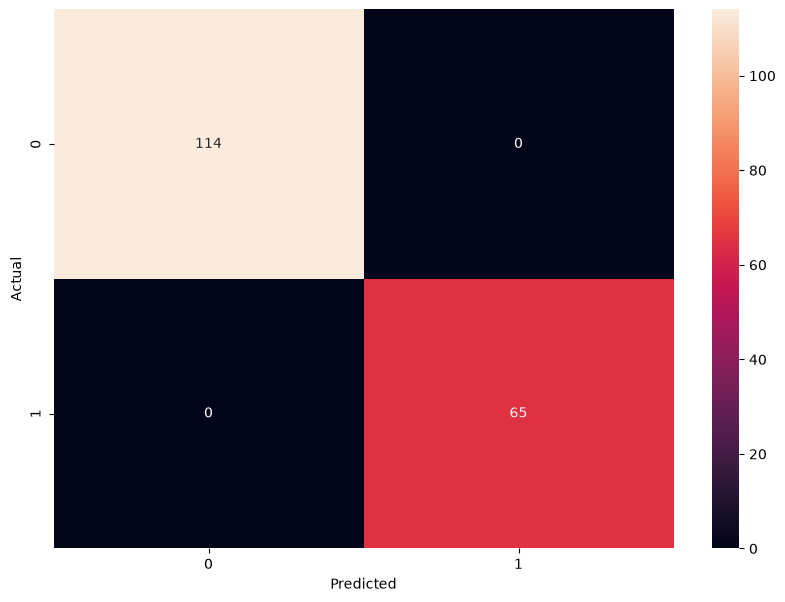

In [71]:
# Plot the Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [72]:
# Save the Model
import pickle
pickle.dump(model, open('./saved_models/02_model_logistic_regression.pkl', 'wb'))

## 🎯 Logistic Regression — Final Takeaway

### 🔑 What We Practiced

* 🏷️ Used **Logistic Regression for Classification**, not numerical regression.
* 🎯 Understood **Binary, Multi-Class, and One-vs-Rest** classification.
* 📊 Learned how the model uses **probability to choose a class**.
* 🌍 Applied it to real-world classification problems like **Spam Detection** and **Fraud Detection**.

### ⚖️ Remember the Difference

* 📈 **Linear Regression** → Predicts a **continuous number**
* 🏷️ **Logistic Regression** → Predicts a **class/category**

> 💡 **Final Rule:**
> **Number → Linear Regression 📈**
> **Category/Class → Logistic Regression 🏷️**
